# Discrete utility transform

parameter passing is incomplete   AUg 2026

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def discretize_normal_distribution(mean=0, std=1, no_bins=10, x_range=None):
    """
    Compute a continuous normal distribution and discretize it into bins.
    
    Parameters:
    - mean: Mean of the normal distribution
    - std: Standard deviation of the normal distribution
    - no_bins: Number of bins for discretization
    - x_range: Tuple (min, max) for the range of x values. If None, uses mean +/- 4*std
    
    Returns:
    - bin_edges: Edges of the bins
    - bin_probs: Probability mass in each bin
    - x: x values for plotting the continuous distribution
    - y: Probability density for plotting
    """
    if x_range is None:
        x_range = (mean - 4*std, mean + 4*std)
    
    # Create bin edges
    bin_edges = np.linspace(x_range[0], x_range[1], no_bins + 1)
    
    # Compute probability in each bin using the CDF
    normal_dist = stats.norm(mean, std)
    bin_probs = np.diff(normal_dist.cdf(bin_edges))
    
    # Continuous distribution for plotting
    x = np.linspace(x_range[0], x_range[1], 1000)
    y = normal_dist.pdf(x)
    
    return dict(bin_edges=bin_edges, bin_probs=bin_probs, x=x, y=y, no_bins=no_bins)

# Test
# discretize_normal_distribution()


ValueError: too many values to unpack (expected 2)

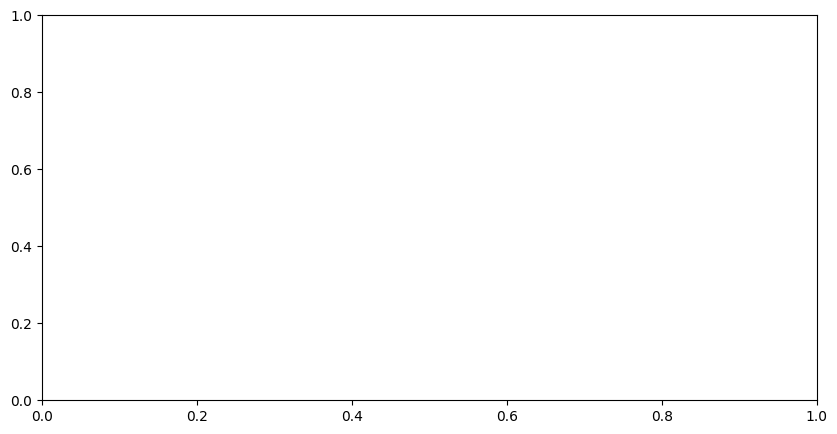

In [2]:
def utility_density_plot(**two_cdfs):
    """
    Plot the probability density of a utility for two distributions
    given as CDFs, comparing their densities on the same axes.

    Parameters are passed as keyword arguments and collected into the
    **two_cdfs dictionary. The dictionary is parsed to create a local
    variable for each named CDF (e.g. utility_density_plot(continuous=cdf_cont,
    discrete=cdf_disc) makes ``continuous`` and ``discrete`` available
    as local names inside the function).

    Each value in **two_cdfs is expected to be a tuple (bin_edges, cdf)
    where:
      - bin_edges: 1-D array of bin edges (length n+1 for n bins)
      - cdf:       1-D array of CDF values at each bin edge (length n+1)

    The density is computed as the discrete difference of consecutive CDF
    values divided by the bin width, and is plotted as a bar chart for
    each named distribution so the continuous and discretized versions
    can be compared visually.
    """
    # Parse the **two_cdfs dictionary into local variables.
    # After this call, every key in two_cdfs becomes a local variable
    # whose value is the corresponding (bin_edges, cdf) tuple.
    locals().update(two_cdfs)

    fig, ax = plt.subplots(figsize=(10, 5))
    max_density = 0.0

    for name, (bin_edges, cdf) in two_cdfs.items():
        # Density = probability mass per unit x in each bin
        bin_widths = np.diff(bin_edges)
        bin_probs = np.diff(cdf)
        density = bin_probs / bin_widths
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        if len(density) > 0:
            max_density = max(max_density, float(np.max(density)))

        ax.bar(bin_centers, density, width=bin_widths, alpha=0.5,
               edgecolor='black', label=name)

    # Overlay a continuous density (if any local variable named 'continuous'
    # was supplied and exposes a .pdf via scipy.stats) for reference.
    if 'continuous' in two_cdfs and hasattr(continuous, 'pdf'):
        edges = two_cdfs['continuous'][0]
        x = np.linspace(edges[0], edges[-1], 1000)
        ax.plot(x, continuous.pdf(x), 'k--', linewidth=1.5,
                label='continuous pdf')

    ax.set_xlabel('Value')
    ax.set_ylabel('Probability Density')
    ax.set_title('Utility Density: Discrete vs Continuous')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

utility_density_plot(**discretize_normal_distribution())
